In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/data_2.csv")

In [3]:
Churchill = df[df["churchill"]==1]
Lyon = df[df["churchill"]==0]

In [4]:
variables = ["price", "risk", "acres", "sqft", "age"]

balance_test = []
balance_test = []

for var in variables:
    
    obs_lyon = Lyon[var].count()
    obs_churchill = Churchill[var].count()
    
    mean_lyon = Lyon[var].mean()
    mean_churchill = Churchill[var].mean()
    
    std_dev_lyon = Lyon[var].std()
    std_dev_churchill = Churchill[var].std()
    
    balance_test.append({
        "Variable": var,
        "Lyon Obs": obs_lyon,
        "Lyon Mean": mean_lyon,
        "Lyon Std Dev": std_dev_lyon,
        "Churchill Obs": obs_churchill,
        "Churchill Mean": mean_churchill,
        "Churchill Std Dev": std_dev_churchill
    })

    
balance_table = pd.DataFrame(balance_test)
balance_table

,Variable,Lyon Obs,Lyon Mean,Lyon Std Dev,Churchill Obs,Churchill Mean,Churchill Std Dev
0,price,2660,215619.685298,41840.152268,2732,213894.765918,42552.810651
1,risk,2660,0.000000,0.000000,2732,0.264926,0.539631
2,acres,2660,2.573622,1.408229,2732,2.580670,1.405640
3,sqft,2660,25.083848,9.030178,2732,25.320870,8.855095
4,age,2660,29.711278,14.640255,2732,30.331625,15.145306


Lyon appears to be similar in observable characterisitcs, house prices and average lot size seem similar. The standard deviation of house prices in both counties are near level, suggesting it may have a similarities. However, 'risk' is not observable in Lyon because they do not have a cluster of cancer patients. This means that the counties differ structurally in health risk exposure and may not represent the counterfactual, limiting its validity as a control group.

In [5]:
df.columns

Index(['parcel', 'year', 'month', 'price', 'risk', 'acres', 'sqft', 'age',
       'class', 'churchill'],
      dtype='object')

In [6]:
df["age_sqr"] = df["age"] * df["age"]
df["acres_sqr"] = df["acres"] * df["acres"]

y = np.log(df["price"])

x = df[["risk", "acres", "acres_sqr", "age",
       "age_sqr", "sqft", "class"]]

x = sm.add_constant(x)
reg1 = sm.OLS(y,x).fit()
reg1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                 1.041e+04
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:45:11   Log-Likelihood:                 8117.1
No. Observations:                5392   AIC:                        -1.622e+04
Df Residuals:                    5384   BIC:                        -1.617e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.6874      0.005   2547.129      0.000      11.678      11.696
risk          -0.0266      0.002    -14.659      0.000      -0.030      -0.023
acres          0.1128      0.002     51.076      0.000       0.108       0.117
acres_sqr     -0.0034      0.000     -8.238      0.000      -0.004      -0.003
age           -0.0036      0.000    -16.893      0.000      -0.004      -0.003
age_sqr    -5.366e-06   3.44e-06     -1.561      0.119   -1.21e-05    1.37e-06
sqft           0.0145   8.19e-05    176.568      0.000       0.014       0.015
class          0.0247      0.001     38.080      0.000       0.023       0.026
==============================================================================
Omnibus:                      249.200   Durbin-Watson:                   1.750
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              395.839
Skew:                          -0.402   Prob(JB):                     1.11e-86
Kurtosis:                       4.057   Cond. No.                     9.48e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.48e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

α$_{i}$ represents the house fixed effects – characteristics that are time invariant (constant across "t") but vary for each property (i). This includes unobservable property factors like the bedroom view, or other amenities that don’t change year to year but do affect price.

#### Fixed Effects Transformation:
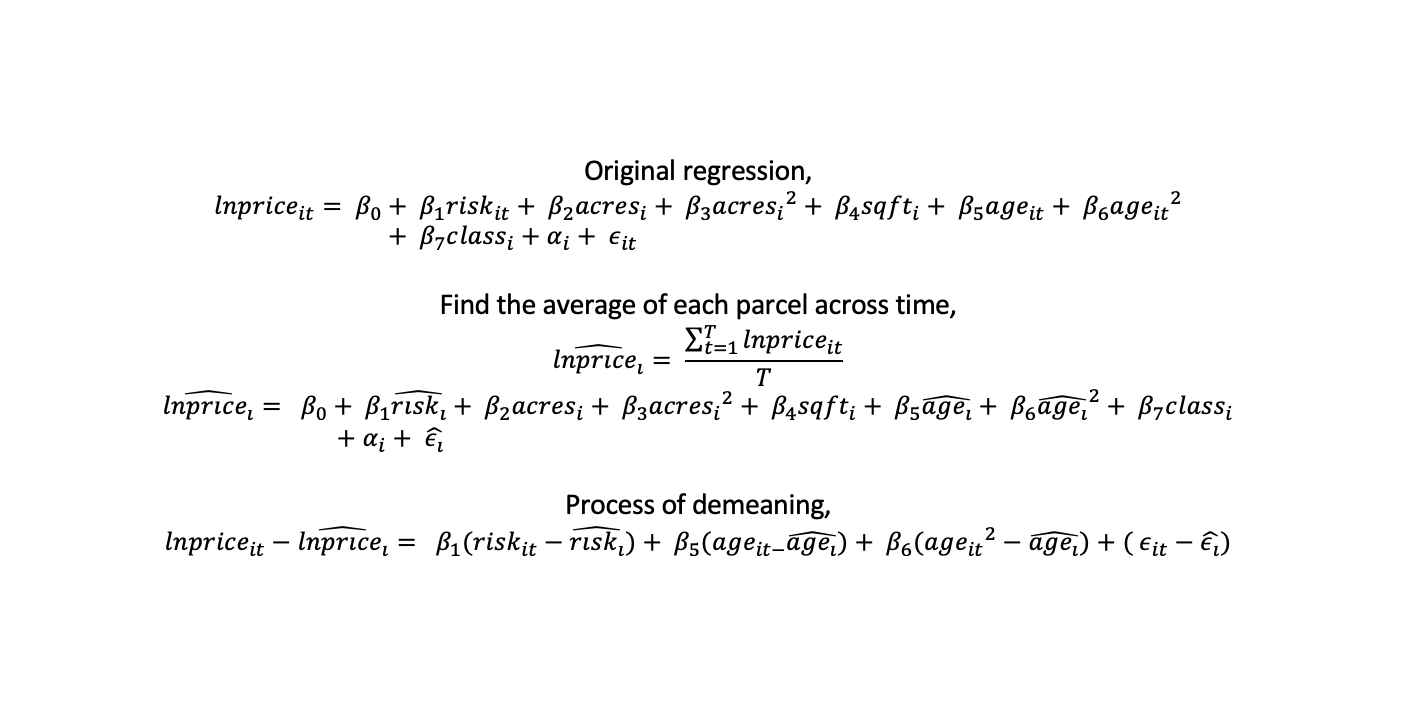
The fixed effects transformation uses a process of demeaning the data to remove time invariant fixed effects. This is done by subtracting each house’s average value from its observed one, eliminating α$_{i}$ from the regression and preventing bias.

In [7]:
df["ln_price"] = np.log(df["price"])

df["ln_price_dm"] = df["ln_price"] - df.groupby("parcel")["ln_price"].transform("mean")
df["risk_dm"] = df["risk"] - df.groupby("parcel")["risk"].transform("mean")
df["age_dm"] = df["age"] - df.groupby("parcel")["age"].transform("mean")
df["age_sqr_dm"] = df["age_sqr"] - df.groupby("parcel")["age_sqr"].transform("mean")

y = df["ln_price_dm"]

x = df[["risk_dm", "acres", "acres_sqr", "age_dm",
       "age_sqr_dm", "sqft", "class"]]

x = sm.add_constant(x)
reg2 = sm.OLS(y,x).fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            ln_price_dm   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     129.4
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.37e-176
Time:                        14:45:11   Log-Likelihood:                 9265.1
No. Observations:                5392   AIC:                        -1.851e+04
Df Residuals:                    5384   BIC:                        -1.846e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.892e-17      0.003   1.31e-14      1.000      -0.006       0.006
risk_dm       -0.0245      0.002    -12.555      0.000      -0.028      -0.021
acres       4.586e-17      0.002   2.57e-14      1.000      -0.003       0.003
acres_sqr  -5.096e-18      0.000  -1.52e-14      1.000      -0.001       0.001
age_dm        -0.0029      0.000     -7.178      0.000      -0.004      -0.002
age_sqr_dm -1.113e-05   5.89e-06     -1.888      0.059   -2.27e-05    4.29e-07
sqft        -1.65e-18   6.62e-05  -2.49e-14      1.000      -0.000       0.000
class       4.554e-18      0.001   8.67e-15      1.000      -0.001       0.001
==============================================================================
Omnibus:                       87.749   Durbin-Watson:                   2.410
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              145.061
Skew:                          -0.139   Prob(JB):                     3.17e-32
Kurtosis:                       3.754   Cond. No.                     1.25e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.25e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In model (2), the coefficient on risk is estimated using both between-house and within-house variation. This means it captures the causal effect of risk on prices, but may also reflect permanent differences across properties that are correlated with risk. If higher-risk houses are located in areas with lower baseline quality, the pooled OLS estimate may overstate the negative impact of risk.

In model (4), fixed effects remove time-invariant house characteristics, so β$_{1}$ is identified purely from within-house changes in risk over time. Comparing the two models, β$_{1}$ becomes less negative, moving from −2.66% to −2.45%. This suggests that the previous model slightly overstated the negative effect of risk due to omitted time invariant characteristics.

In [8]:
df["pt"] = (df["year"] >= 2000)

In [9]:
group_means = df.groupby(["churchill", "pt"])["ln_price"].mean()
group_means

churchill  pt   
0          False    12.266428
           True     12.245054
1          False    12.264127
           True     12.210295
Name: ln_price, dtype: float64

In [10]:
C_pre = group_means.loc[(1,False)]
C_post = group_means.loc[(1,True)]
L_pre = group_means.loc[(0,False)]
L_post = group_means.loc[(0,True)]

diff_C = C_post - C_pre
diff_L = L_post - L_pre

DiD = diff_C - diff_L

DiD

-0.03245898260286317

In [11]:
table = pd.DataFrame({
    "County": ["Churchill", "Lyon", "-"],
    "Pre-Trearment": [C_pre, L_pre, "-"],
    "Post-Treatment": [C_post, L_post, "DiD="],
    "Difference": [diff_C, diff_L, DiD]
})

table

,County,Pre-Trearment,Post-Treatment,Difference
0,Churchill,12.264127,12.210295,-0.053833
1,Lyon,12.266428,12.245054,-0.021374
2,-,-,DiD=,-0.032459


The key assumption of this DID is that it follows parallel trends. In the absence of any treatment, Churchill and Lyon houses would follow similar time trends in housing prices. This does not necessarily mean that they would have the same levels of prices, but rather a similar growth trend.

In model (4) this assumption is not made as it compares the same house before and after treatment, controlling for its unobserved time invariant characteristics. Therefore, the fixed effects model (4) may differ from the difference-in-difference estimate, as model (6) relies on a strong assumption of parallel trends across houses and does not account for time varying differences between counties. Any difference in the coefficient of risk would reflect the models different identifying assumptions.